**Breast Cancer Diagnosis**

Dataset: Breast Cancer Wisconsin (Diagnostic) Data Set

File: breast_cancer_dataset.csv

Dataset details: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

1. Setup

In [50]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [51]:
# import dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [52]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style="darkgrid")
RANDOM_STATE=42

**2. Load dataset**

In [53]:
df = pd.read_csv("breast_cancer_dataset (1).csv")

In [54]:
df.shape

(569, 32)

In [55]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [56]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,842517,M,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,84300903,M,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,84348301,M,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,84358402,M,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077


In [57]:
df = df.drop(columns="id")

In [58]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,M,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,M,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,M,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,M,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077


**3. Exploratory Data Analysis(EDA)**

In [59]:
# check presence of missing values

df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [ ]:
# check if there is any encoded missing values - top repeated values
for col in df.columns:
    print(df[col].value_counts().head(10)) 

diagnosis
B    357
M    212
Name: count, dtype: int64
radius_mean
12.340    4
11.060    3
13.050    3
10.260    3
12.890    3
11.600    3
13.000    3
11.710    3
12.770    3
11.890    3
Name: count, dtype: int64
texture_mean
15.700    3
18.220    3
20.520    3
19.830    3
14.930    3
17.460    3
18.900    3
16.850    3
16.840    3
20.250    2
Name: count, dtype: int64
perimeter_mean
82.610     3
134.700    3
87.760     3
129.100    2
82.690     2
132.900    2
130.000    2
81.350     2
94.250     2
58.790     2
Name: count, dtype: int64
area_mean
512.200     3
658.800     2
684.500     2
1076.000    2
1075.000    2
716.600     2
520.000     2
394.100     2
561.000     2
466.100     2
Name: count, dtype: int64
smoothness_mean
0.101    5
0.107    4
0.105    4
0.115    4
0.105    3
0.117    3
0.098    3
0.104    3
0.102    3
0.104    3
Name: count, dtype: int64
compactness_mean
0.115    3
0.121    3
0.170    2
0.105    2
0.131    2
0.114    2
0.050    2
0.057    2
0.077    2
0.131    2
Nam

In [62]:
# identify duplicate rows
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()

print("Number of duplicated rows:", num_duplicates)
print("Duplicated rows:", df[duplicate_mask])

Number of duplicated rows: 0
Duplicated rows: Empty DataFrame
Columns: [diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []


In [63]:
# class distribution

print(df["diagnosis"].value_counts())

print(df["diagnosis"].value_counts(normalize=True)*100)

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B   62.742
M   37.258
Name: proportion, dtype: float64


In [64]:
# encode categorical columns

df["diagnosis"] = df["diagnosis"].map({"B": 0, "M":1})

In [65]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,1,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,1,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,1,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,1,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077


In [66]:
# class distribution

print(df["diagnosis"].value_counts())

print(df["diagnosis"].value_counts(normalize=True)*100)

diagnosis
0    357
1    212
Name: count, dtype: int64
diagnosis
0   62.742
1   37.258
Name: proportion, dtype: float64


In [67]:
df.groupby("diagnosis").mean()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,12.147,17.915,78.075,462.790,0.092,0.080,0.046,0.026,0.174,0.063,0.284,1.220,2.000,21.135,0.007,0.021,0.026,0.010,0.021,0.004,13.380,23.515,87.006,558.899,0.125,0.183,0.166,0.074,0.270,0.079
1,17.463,21.605,115.365,978.376,0.103,0.145,0.161,0.088,0.193,0.063,0.609,1.211,4.324,72.672,0.007,0.032,0.042,0.015,0.020,0.004,21.135,29.318,141.370,1422.286,0.145,0.375,0.451,0.182,0.323,0.092


**4. Data Visualization**

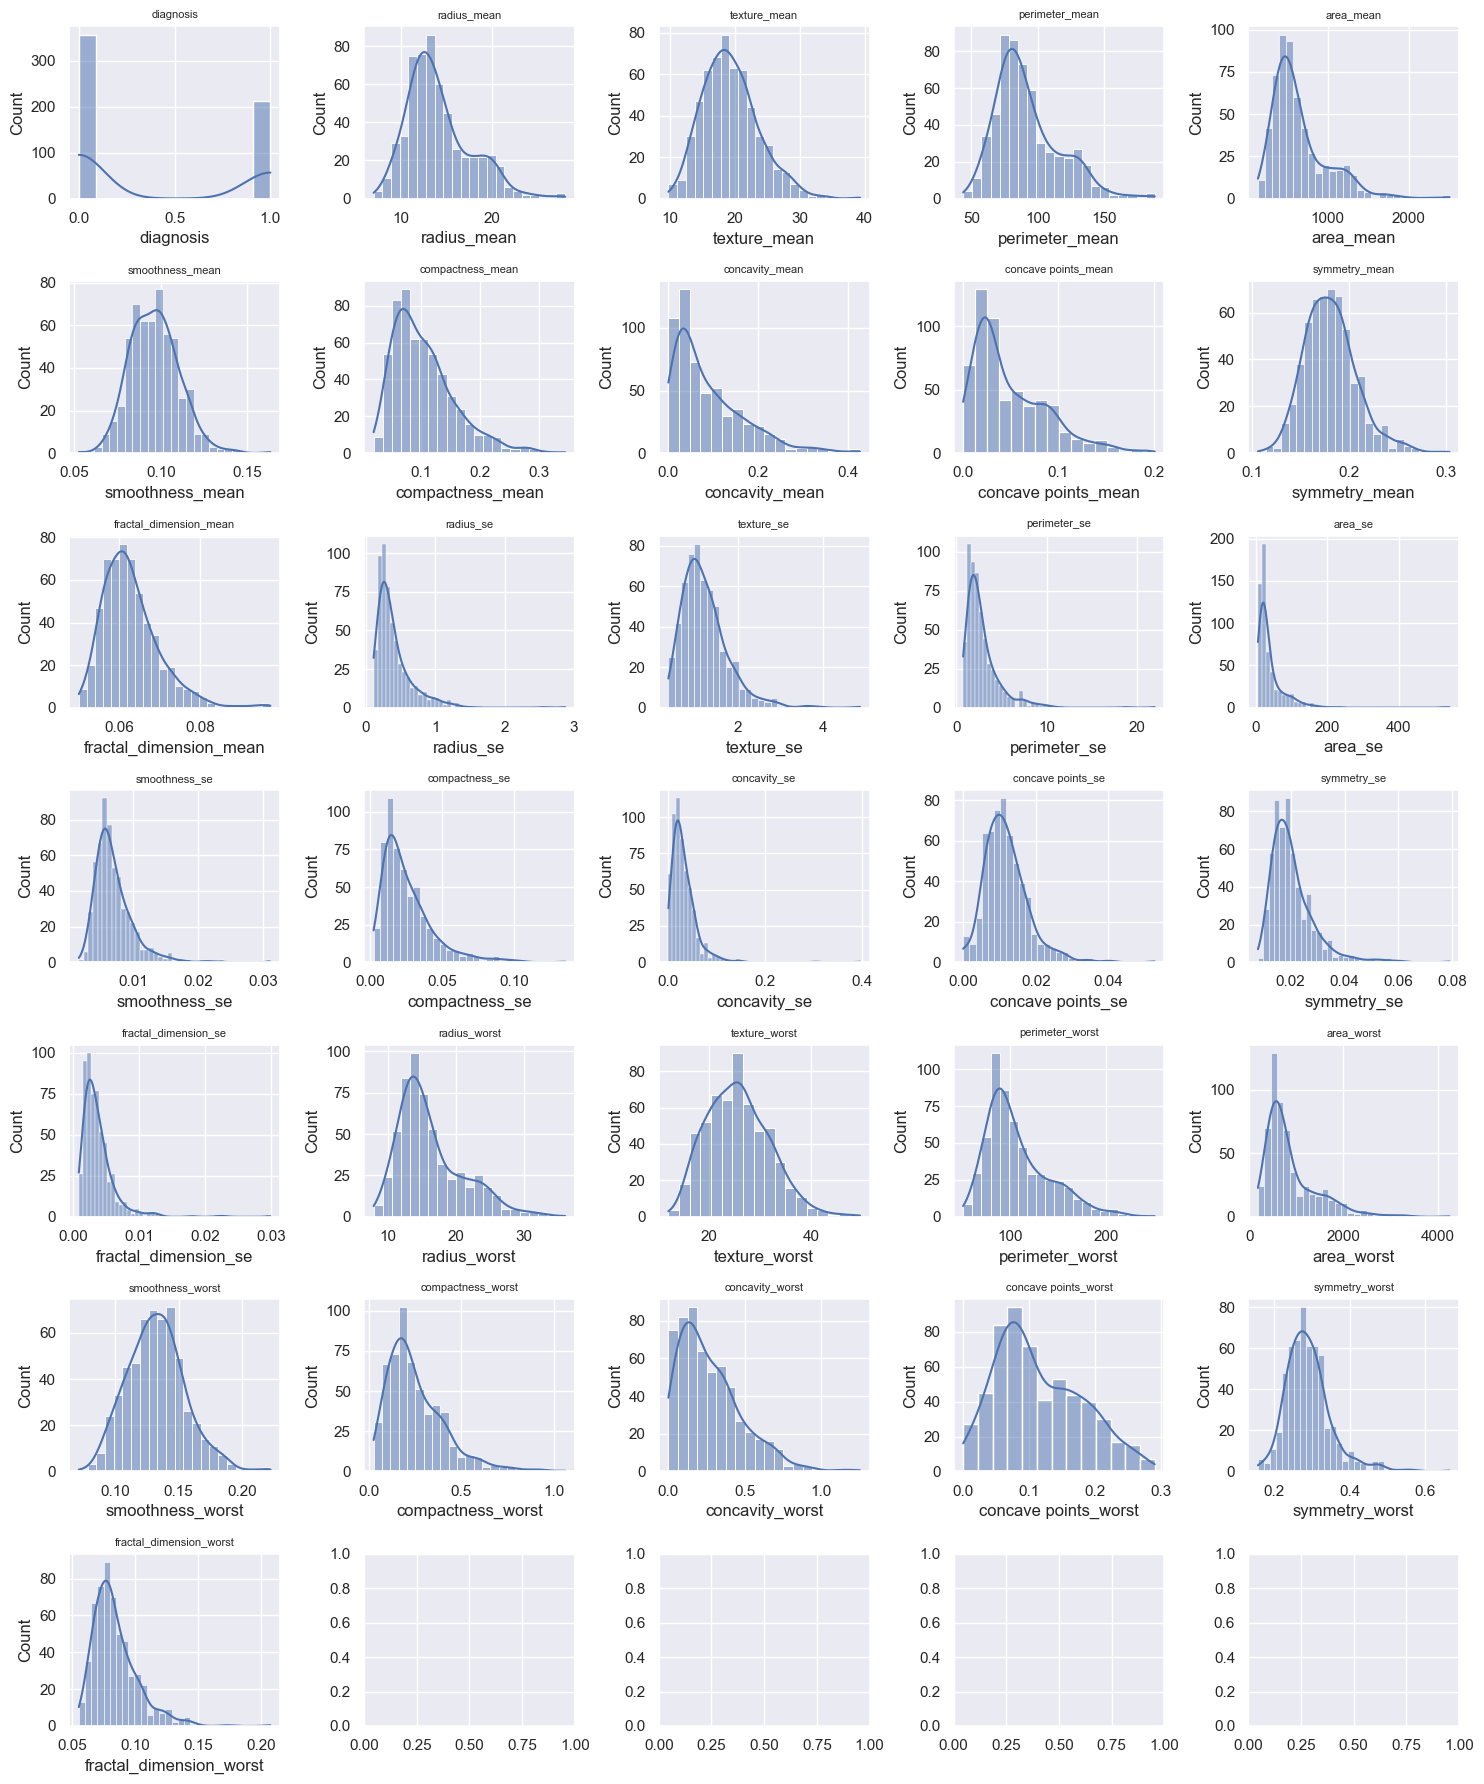

In [68]:
# histogram plot - distribution

fig, axes = plt.subplots(7, 5, figsize=(15,18))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

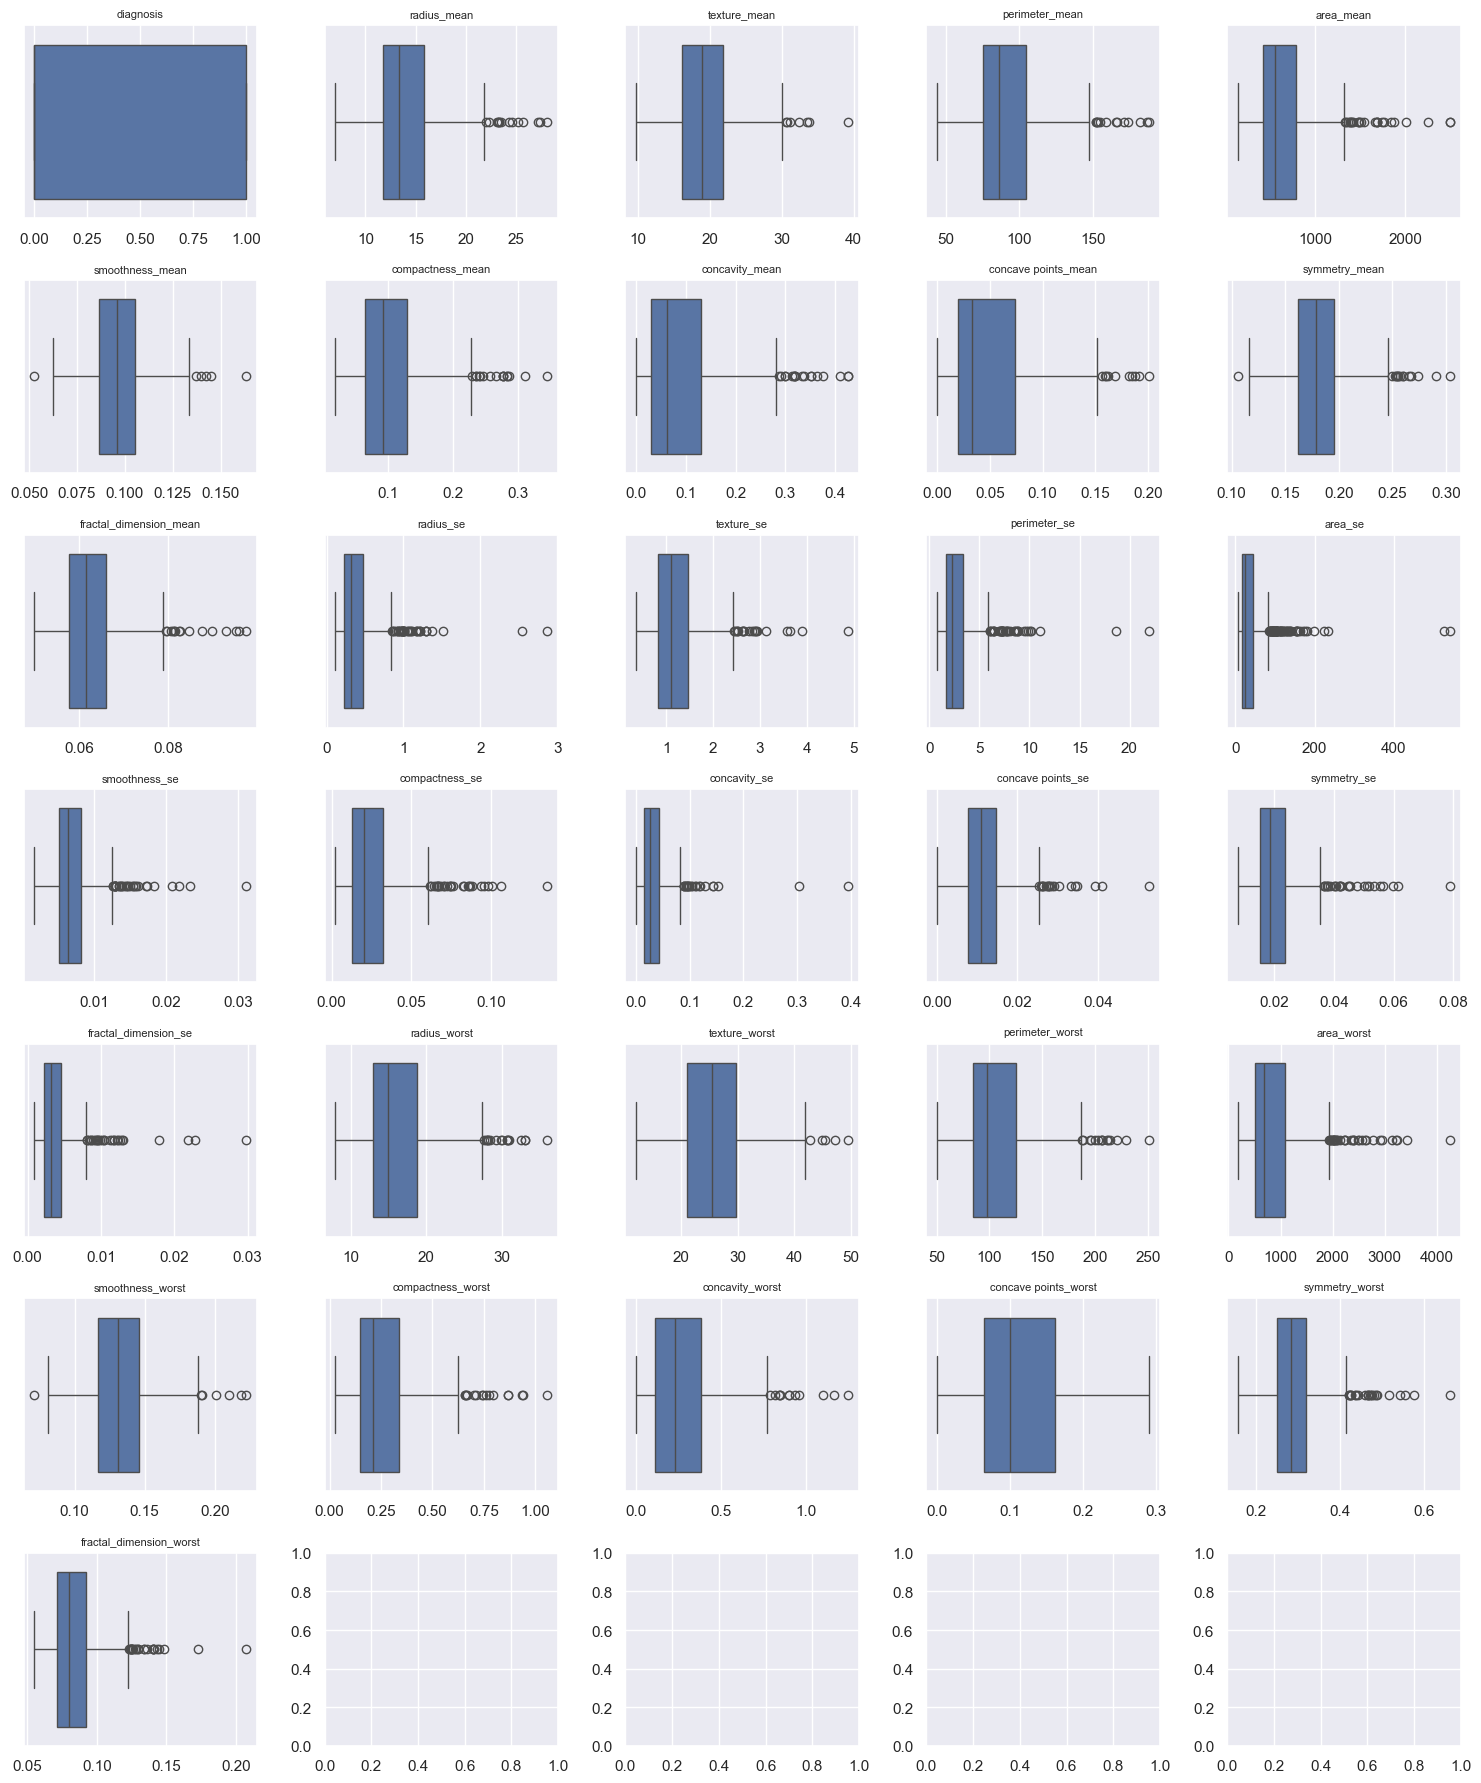

In [69]:
# boxplot for checking the outliers

fig, axes = plt.subplots(7, 5, figsize=(15,18))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

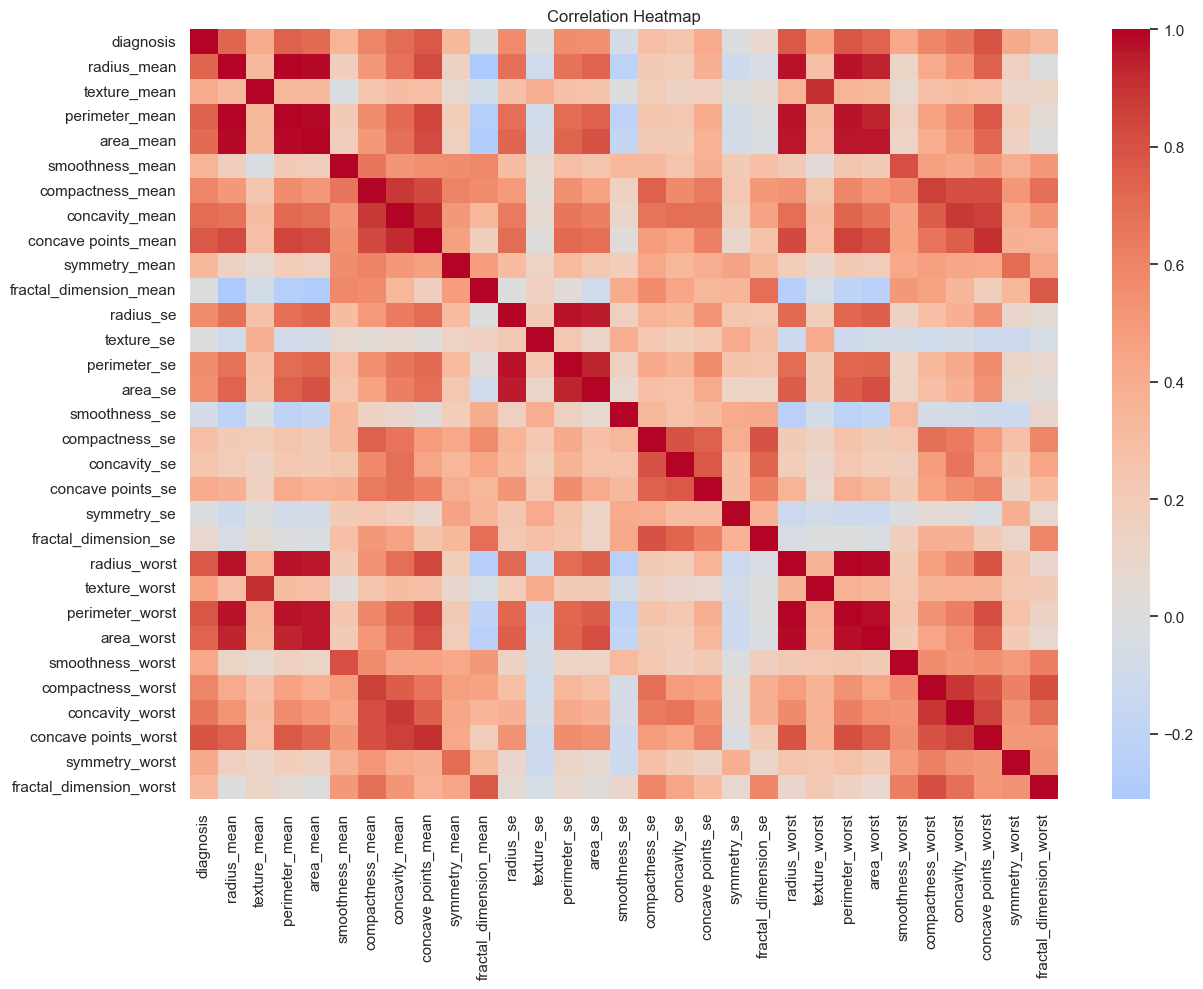

In [70]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

**Insights:**
- Drop the id column
- All features are numerical, no categorical variables
- High-dimensional feature space
- No missing values
- Slight class imbalance, address after baseline using precision and recall
- Recall is the priority metric since false negatives are critical
- Strong separation in feature means between classes
- Extreme values often represent malignant cases, not noise
- Highly correlated features present. We can perform feature selection / PCA

**5. Data pre-processing**

In [71]:
# separate data into features and target

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [72]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [73]:
print("Dataset shape:", X.shape)
print("training data shape:", X_train.shape)
print("test data shape:", X_test.shape)

Dataset shape: (569, 30)
training data shape: (455, 30)
test data shape: (114, 30)


**6. Baseline Model - Logistic Regression**

In [74]:
scaler = StandardScaler()

In [75]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [76]:
model = LogisticRegression()

In [77]:
# training model

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [78]:
# training model accuracy

model.score(X_train_scaled, y_train)

0.9868131868131869

In [79]:
# test model accuracy
model.score(X_test_scaled, y_test)

0.9649122807017544

**7. Model Optimization**

In [81]:
# create pipeline

pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA()),
        ("model", SVC())
    ]
)

In [ ]:
# create grid hyperparameters

param_grid = [
    {
        "pca__n_components": [10, 15, 20, 25, 30],
        "model__C": [0.1, 1, 10, 100, 1000],
        "model__gamma": [0.001, 0.01, 0.1, 1]
    }
]

In [ ]:
# cross validation setup(used inside grid search cv)

k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [89]:
# hyperparamter tuning

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="recall",
    cv=skf,
    n_jobs=-1
)

In [90]:
grid_search.fit(X_train, y_train)

,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"[{'model__C': [0.1, 1, ...], 'model__gamma': [0.001, 0.01, ...], 'pca__n_components': [10, 15, ...]}]"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [91]:
print("Hyperparameter Tuning result:")
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Hyperparameter Tuning result:
Best params: {'model__C': 1000, 'model__gamma': 0.01, 'pca__n_components': 15}
Best score: 0.9647058823529411


**8. Train with best params**

In [96]:
best_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=15)),
        ("model", SVC(kernel="rbf", C=10, gamma=0.01))
    ]
)

In [97]:
# train the pipeline

best_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,15
,copy,True
,whiten,False
,svd_solver,'auto'


**9. Model Evaluation**

In [98]:
# training data predictions
y_train_pred = best_pipeline.predict(X_train)

In [99]:
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Traning accucracy: {round(train_acc*100, 2)}%")


Traning accucracy: 98.68%


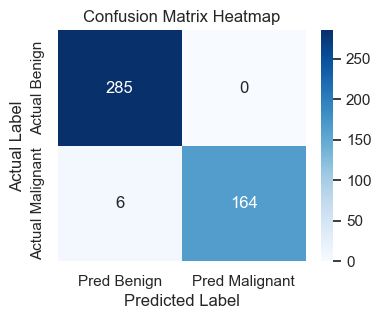

In [100]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(4,3))
# heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Benign", "Pred Malignant"],
    yticklabels=["Actual Benign", "Actual Malignant"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [101]:
print("Training Classification report")
print(classification_report(y_train, y_train_pred))

Training Classification report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       285
           1       1.00      0.96      0.98       170

    accuracy                           0.99       455
   macro avg       0.99      0.98      0.99       455
weighted avg       0.99      0.99      0.99       455



In [102]:
# test data prediction
y_test_pred = best_pipeline.predict(X_test)

In [103]:
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {round(test_acc*100, 2)} %")

Test Accuracy: 98.25 %


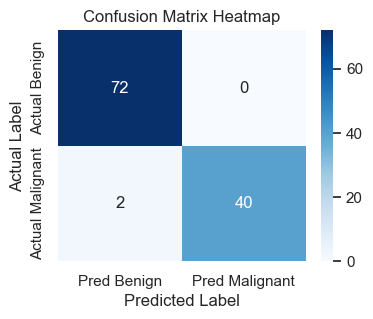

In [104]:
# confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(4,3))
# heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Benign", "Pred Malignant"],
    yticklabels=["Actual Benign", "Actual Malignant"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [105]:
print("Test Classification report")
print(classification_report(y_test, y_test_pred))

Test Classification report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**10. Build pedictive systems**

In [106]:
def predict_cancer(input_features):
    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )
    prediction = best_pipeline.predict(input_df)
    print("Model prediction:", prediction)
    if prediction[0] == 1:
        print("Diagnosis - Malignant 🔴")
    else:
        print("Diagnosis - Benign 🟢")

In [107]:
# sample unknown data point - access from test data index
test_1 = X_test.loc[120].tolist()
print(test_1)

[11.41, 10.82, 73.34, 403.3, 0.09373, 0.06685, 0.03512, 0.02623, 0.1667, 0.06113, 0.1408, 0.4607, 1.103, 10.5, 0.00604, 0.01529, 0.01514, 0.00646, 0.01344, 0.002206, 12.82, 15.97, 83.74, 510.5, 0.1548, 0.239, 0.2102, 0.08958, 0.3016, 0.08523]


In [108]:
predict_cancer(test_1)

Model prediction: [0]
Diagnosis - Benign 🟢


In [109]:
# sample unknown data point - access from test data index
test_2 = X_test.loc[250].tolist()
print(test_2)

[20.94, 23.56, 138.9, 1364.0, 0.1007, 0.1606, 0.2712, 0.131, 0.2205, 0.05898, 1.004, 0.8208, 6.372, 137.9, 0.005283, 0.03908, 0.09518, 0.01864, 0.02401, 0.005002, 25.58, 27.0, 165.3, 2010.0, 0.1211, 0.3172, 0.6991, 0.2105, 0.3126, 0.07849]


In [110]:
predict_cancer(test_2)

Model prediction: [1]
Diagnosis - Malignant 🔴


In [111]:
test_3 = [16.02,23.24,102.7,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,0.3795,1.187,2.466,40.51,0.004029,0.009269,0.01101,0.007591,0.0146,0.003042,19.19,33.88,123.8,1150,0.1181,0.1551,0.1459,0.09975,0.2948,0.08452]
predict_cancer(test_3)

Model prediction: [1]
Diagnosis - Malignant 🔴
